PCA Analysis
==============================================================
Research Questions addressed:

PCA does not directly answer any of the research questions. It is an exploratory, descriptive technique. It has no statistical tests, no p-values, no outcome modeling, and no causal reasoning. It tells you about variance structure among features, not about relationships to an outcome or group differences.

Install libraries (as needed)

In [63]:
# %pip install scikit-learn # <- uncomment to install scikit-learn if needed
# %pip install -U kaleido
# %pip install --upgrade "plotly>=6.1.1" "kaleido>=1.0.0"

Import libraries

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import scale
from sklearn import decomposition
import pandas as pd
import plotly.graph_objects as go 
import kaleido
import plotly.express as px


pd.set_option("display.max_columns", 100)
pd.set_option('display.width',150)  
pd.set_option("display.float_format", lambda x: f'{x:,.4f}')
sns.set_theme(style="whitegrid", context='talk')

Load dataset

In [98]:
ht_risk_df = pd.read_csv('../data/nhanes_hypertension_risk.csv')
ht_risk_df

,participant_id,age,race_ethnicity,education,poverty_income_ratio,marital_status,diagnosed_high_bp,diagnosed_twice,on_chol_medication,bmi,waist_cm,weight_kg,height_cm,smoked_100_cigarettes,smoke_frequency,avg_drinks_per_day,time_sitting,total_cholesterol_mgdl,HDL_cholesterol_mgdl,fasting_glucose_mgdl,LDL_cholesterol_mgdl_friedewald,LDL_cholesterol_mgdl_martin,LDL_cholesterol_mgdl_nih,systolic_avg,systolic_clinical,diastolic_avg,diastolic_clinical,pulse_avg,pulse_clinical,hypertension_risk,male,ever_smoker,current_smoker,drinks_alcohol,drink_frequency_past_year,high_cholesterol,moderate_minutes_per_week,vigorous_minutes_per_week,physically_active
0,130378,43.0000,Non-Hispanic Asian,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,27.0000,98.3000,86.9000,179.5000,1.0000,3.0000,1.3333,360.0000,264.0000,45.0000,113.0000,188.0000,190.0000,191.0000,132.6667,131.5000,96.0000,95.0000,81.0000,80.5000,1,1,1,0,1,208.0000,0,135.0000,135.0000,1
1,130379,66.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,33.5000,114.7000,101.8000,174.2000,1.0000,3.0000,3.0000,480.0000,214.0000,60.0000,125.3333,137.0000,135.0000,139.0000,117.0000,115.0000,78.6667,76.0000,72.0000,72.0000,1,1,1,0,1,300.0000,0,180.0000,135.0000,1
2,130380,44.0000,Other Hispanic,HS/GED or equivalent,1.4100,Married/Living with Partner,0,0.0000,Yes,29.7000,93.5000,69.4000,152.9000,2.0000,3.0000,1.0000,240.0000,187.0000,49.0000,156.0000,63.0000,90.0000,78.0000,109.0000,108.0000,78.3333,78.0000,81.3333,80.0000,1,0,0,0,1,1.0000,1,20.0000,21.9045,0
3,130386,34.0000,Mexican American,Some college or AA degree,1.3300,Married/Living with Partner,0,0.0000,No,30.2000,106.1000,90.6000,173.3000,1.0000,3.0000,2.0000,180.0000,183.0000,46.0000,100.0000,109.0000,111.0000,112.0000,115.0000,117.5000,73.6667,74.5000,62.3333,64.0000,0,1,1,0,1,104.0000,0,30.0000,6.9045,0
4,130394,51.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,0,0.0000,No,24.4000,92.1000,76.7000,177.3000,2.0000,3.0000,1.0000,420.0000,183.0000,48.0000,88.0000,124.0000,120.0000,124.0000,110.6667,116.5000,68.0000,67.5000,79.6667,80.5000,0,1,0,0,1,24.0000,0,0.0000,120.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3557,142301,80.0000,Non-Hispanic White,College graduate or above,1.2000,Widowed/Divorced/Separated,1,1.0000,No,30.5000,79.7000,82.2000,164.3000,1.0000,3.0000,2.0000,360.0000,138.0000,48.0000,110.0000,61.0000,67.0000,65.0000,140.4444,112.1667,75.3333,72.8333,69.7778,79.0000,1,0,1,0,1,1.0000,1,76.4020,21.9045,0
3558,142303,69.0000,Non-Hispanic White,HS/GED or equivalent,0.9800,Widowed/Divorced/Separated,0,0.0000,Yes,27.9000,111.0000,70.8000,159.2000,1.0000,3.0000,0.0000,360.0000,110.0000,34.0000,160.0000,45.0000,53.0000,50.0000,127.0000,126.0000,69.3333,68.5000,75.3333,75.0000,1,0,1,0,0,0.0000,0,840.0000,95.0000,1
3559,142305,76.0000,Mexican American,<HS,2.2500,Widowed/Divorced/Separated,1,1.0000,Yes,26.4000,89.0000,60.4000,151.4000,2.0000,3.0000,1.3333,480.0000,180.0000,51.0000,132.0000,92.0000,101.0000,97.0000,143.6667,146.0000,79.3333,78.5000,70.6667,70.5000,1,0,0,0,1,17.3333,1,80.0000,21.9045,0
3560,142308,50.0000,Other Hispanic,Some college or AA degree,1.9500,Married/Living with Partner,0,0.0000,No,26.4000,98.4000,79.3000,173.3000,2.0000,3.0000,2.0000,600.0000,166.0000,42.6667,112.6667,61.3333,122.6667,88.6667,108.0000,109.0000,69.3333,71.5000,62.6667,65.0000,0,1,0,0,1,8.0000,0,45.0000,24.6030,0


Configuration Settings

In [109]:
output_dir  = "../visualizations/models"
seed = 42
palette = "Set2"

# define feature columns 
feature_cols = [
    'age', 'poverty_income_ratio', 'bmi', 'waist_cm', 'weight_kg', 'height_cm',
    'male', 'ever_smoker', 'current_smoker', 'avg_drinks_per_day',
    'drink_frequency_past_year', 'time_sitting',
    'total_cholesterol_mgdl', 'HDL_cholesterol_mgdl',
    'LDL_cholesterol_mgdl_friedewald', 'fasting_glucose_mgdl',
    'high_cholesterol', 'on_chol_medication', 'pulse_avg',
    'moderate_minutes_per_week', 'vigorous_minutes_per_week', 'physically_active'
]
print(feature_cols)
print(len(feature_cols), 'input features')

# define output feature (target)
target_col = 'hypertension_risk'
print('distribution of target value:\n', ht_risk_df[target_col].value_counts())

['age', 'poverty_income_ratio', 'bmi', 'waist_cm', 'weight_kg', 'height_cm', 'male', 'ever_smoker', 'current_smoker', 'avg_drinks_per_day', 'drink_frequency_past_year', 'time_sitting', 'total_cholesterol_mgdl', 'HDL_cholesterol_mgdl', 'LDL_cholesterol_mgdl_friedewald', 'fasting_glucose_mgdl', 'high_cholesterol', 'on_chol_medication', 'pulse_avg', 'moderate_minutes_per_week', 'vigorous_minutes_per_week', 'physically_active']
22 input features
distribution of target value:
 hypertension_risk
1    2145
0    1417
Name: count, dtype: int64


---

Additional Transformations Needed for PCA

In [118]:
# Convert Yes/No fields to binary 1/0
ht_risk_model = ht_risk_df.copy()
ht_risk_model['on_chol_medication'] = ht_risk_model['on_chol_medication'].map({'No': 0, 'Yes': 1})

X = ht_risk_model[feature_cols].values
Y = ht_risk_model[target_col].values

# Scale data
X = scale(X)

# Examine shape:
print(X.shape)  # rows = participants, columns = input risk-factor features
print(Y.shape)  # one hypertension_risk label per participant

print("\nScaled data snapshot: \n")
print(pd.DataFrame(X, columns=feature_cols, index=ht_risk_model.index).head(10))

(3562, 22)
(3562,)

Scaled data snapshot: 

      age  poverty_income_ratio     bmi  waist_cm  weight_kg  height_cm    male  ever_smoker  current_smoker  avg_drinks_per_day  \
0 -0.5289                1.2611 -0.3562   -0.1099     0.1765     1.2343  1.1055       1.2619         -0.3353             -0.3755   
1  0.7499                1.2611  0.5230    0.8560     0.8419     0.7025  1.1055       1.2619         -0.3353              0.5349   
2 -0.4733               -1.0094  0.0090   -0.3926    -0.6051    -1.4349 -0.9046      -0.7924         -0.3353             -0.5576   
3 -1.0294               -1.0600  0.0767    0.3495     0.3417     0.6121  1.1055       1.2619         -0.3353             -0.0113   
4 -0.0841                1.2611 -0.7078   -0.4751    -0.2791     1.0135  1.1055      -0.7924         -0.3353             -0.5576   
5 -1.0850               -1.2055  3.3768    2.4934     2.4766    -0.8027 -0.9046      -0.7924         -0.3353             -0.5576   
6  0.1939                1.1472 

PCA Analysis

1 Define number of principal components

Here we define the number of PC to use. To choose a defensible number of components, we refit PCA keeping **all 22** components (no information lost) and look at:
- **Kaiser's rule**: keep components with eigenvalue > 1 (a component should explain at least as much variance as one original standardized 
variable).
- **Cumulative variance thresholds**: how many components are needed to capture 70% / 80% of total variance.

1.1 Identify the eigenvalues, explained variance, and cumulative variance for each PC

In [68]:
pca_full = decomposition.PCA(n_components=len(feature_cols))
pca_full.fit(X)


eigenvalues_full = pca_full.explained_variance_
explained_variance_full = pca_full.explained_variance_ratio_
cumulative_variance_full = np.cumsum(explained_variance_full)


df_full = pd.DataFrame({
    'PC': [f'PC{i}' for i in range(1, len(feature_cols) + 1)],
    'Eigenvalue': eigenvalues_full,
    'Explained Variance': explained_variance_full,
    'Cumulative Variance': cumulative_variance_full
})
df_full

,PC,Eigenvalue,Explained Variance,Cumulative Variance
0,PC1,3.2366,0.1471,0.1471
1,PC2,2.3490,0.1067,0.2538
2,PC3,2.1894,0.0995,0.3533
3,PC4,1.9115,0.0869,0.4402
4,PC5,1.6816,0.0764,0.5166
5,PC6,1.4788,0.0672,0.5838
6,PC7,1.1288,0.0513,0.6351
7,PC8,1.0625,0.0483,0.6834
8,PC9,0.9113,0.0414,0.7248
9,PC10,0.8306,0.0377,0.7625


1.2 Identify the cutoff point for each threshold (70%/80% of variace explained)

In [69]:
n_kaiser = int((eigenvalues_full > 1).sum())
n_70 = int(np.argmax(cumulative_variance_full >= 0.70) + 1)
n_80 = int(np.argmax(cumulative_variance_full >= 0.80) + 1)


print(f"Kaiser's rule (eigenvalue > 1):        {n_kaiser} components")
print(f"Components needed for >=70% variance:  {n_70} components")
print(f"Components needed for >=80% variance:  {n_80} components")

Kaiser's rule (eigenvalue > 1):        8 components
Components needed for >=70% variance:  9 components
Components needed for >=80% variance:  12 components


1.3 Eigenvalue plot with the Kaiser cutoff (eigenvalue = 1)

In [70]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_full['PC'],
    y=df_full['Eigenvalue'],
    marker=dict(color=['SeaGreen' if e > 1 else 'LightGray' for e in df_full['Eigenvalue']]),
    name='Eigenvalue'
))

fig.add_hline(y=1, line_dash='dash', line_color='black',
              annotation_text='Kaiser cutoff (eigenvalue = 1)', annotation_position='top right')

fig.update_layout(
    title=f"Eigenvalues per Component — Kaiser's Rule Retains {n_kaiser} PCs",
    xaxis_title='Principal Component',
    yaxis_title='Eigenvalue',
    width=950, height=500
)

fig.write_image(f"{output_dir}/C1.1_eigenvalue_plot.png")
fig.show()
print("✔ Saved: C1.1_eigenvalue_plot.png\n")

✔ Saved: C1.1_eigenvalue_plot.png



1.4  Scree plot with 70%/80% thresholds

In [71]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_full['PC'],
    y=df_full['Explained Variance'] * 100,
    name='Explained Variance (%)',
    marker=dict(color='RoyalBlue')
))

fig.add_trace(go.Scatter(
    x=df_full['PC'],
    y=df_full['Cumulative Variance'] * 100,
    name='Cumulative Variance (%)',
    mode='lines+markers',
    marker=dict(size=8, color='LightSeaGreen')
))

# Reference lines for the 70% / 80% cumulative-variance thresholds
fig.add_hline(y=70, line_dash='dash', line_color='orange',
              annotation_text='70% cumulative variance', annotation_position='bottom right')
fig.add_hline(y=80, line_dash='dash', line_color='firebrick',
              annotation_text='80% cumulative variance', annotation_position='top right')

# Mark where each threshold is actually crossed
fig.add_vline(x=n_70 - 1, line_dash='dot', line_color='orange')
fig.add_vline(x=n_80 - 1, line_dash='dot', line_color='firebrick')

fig.update_layout(
    title='Full Scree Plot — All 22 Principal Components',
    xaxis_title='Principal Component',
    yaxis_title='Variance Explained (%)',
    width=950, height=550,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.write_image(f"{output_dir}/C1.2_scree_full.png")
fig.show()
print("✔ Saved: C1.2_scree_full.png\n")

✔ Saved: C1.2_scree_full.png



**Based on the above analysis, we will select 9 PCs for our model**

2.1 Define number of PCs to use as 9

In [72]:
pca = decomposition.PCA(n_components=9)
pca.fit(X)

PCA(n_components=9)

2. Compute and retrieve the **scores** values

In [73]:
scores = pca.transform(X) # the W matrix

In [74]:
scores_df = pd.DataFrame(scores, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6',' PC7', 'PC8', 'PC9'])
scores_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-0.4076,1.6626,-2.0809,2.3016,0.2388,-1.0144,-1.0064,0.8952,0.1863
1,1.0168,1.9528,-1.0524,2.0818,-0.2606,-0.9279,1.0097,-0.2267,-0.2655
2,0.0819,-2.1147,1.9040,-1.0175,0.2397,1.1882,-0.4834,1.4873,-1.0945
3,0.5721,0.6084,-0.9494,-0.8181,1.1147,-0.4693,-1.0799,-1.5186,-0.4899
4,-0.7441,1.1345,-0.9893,-0.5562,-0.9751,-0.9691,-0.9135,0.9584,0.4458
...,...,...,...,...,...,...,...,...,...
3557,0.2084,-1.0928,1.8548,-1.1790,0.8882,0.2512,0.0895,-0.6623,0.4281
3558,0.9678,0.2078,2.4061,-1.7310,0.3561,3.0550,-0.1629,0.5844,0.8649
3559,-0.4472,-2.0986,2.6237,-0.1303,-0.3023,0.2071,-0.1428,0.9286,0.0762
3560,0.4181,0.4317,-0.1624,-2.1385,-0.0627,-1.0924,-0.8354,-0.0411,0.3939


2.2 Add the class label into the data frame

In [75]:
Y_label = []


for i in Y:
  if i == 1:
    Y_label.append('Hypertension risk')
  else:
    Y_label.append('No hypertension risk')


Risk = pd.DataFrame(Y_label, columns=['Hypertension Status'])

In [76]:
df_scores = pd.concat([scores_df, Risk], axis=1) 
df_scores

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Hypertension Status
0,-0.4076,1.6626,-2.0809,2.3016,0.2388,-1.0144,-1.0064,0.8952,0.1863,Hypertension risk
1,1.0168,1.9528,-1.0524,2.0818,-0.2606,-0.9279,1.0097,-0.2267,-0.2655,Hypertension risk
2,0.0819,-2.1147,1.9040,-1.0175,0.2397,1.1882,-0.4834,1.4873,-1.0945,Hypertension risk
3,0.5721,0.6084,-0.9494,-0.8181,1.1147,-0.4693,-1.0799,-1.5186,-0.4899,No hypertension risk
4,-0.7441,1.1345,-0.9893,-0.5562,-0.9751,-0.9691,-0.9135,0.9584,0.4458,No hypertension risk
...,...,...,...,...,...,...,...,...,...,...
3557,0.2084,-1.0928,1.8548,-1.1790,0.8882,0.2512,0.0895,-0.6623,0.4281,Hypertension risk
3558,0.9678,0.2078,2.4061,-1.7310,0.3561,3.0550,-0.1629,0.5844,0.8649,Hypertension risk
3559,-0.4472,-2.0986,2.6237,-0.1303,-0.3023,0.2071,-0.1428,0.9286,0.0762,Hypertension risk
3560,0.4181,0.4317,-0.1624,-2.1385,-0.0627,-1.0924,-0.8354,-0.0411,0.3939,No hypertension risk


2.3 Retrieve the loadings values

In [77]:
loadings = pca.components_.T
df_loadings = pd.DataFrame(loadings, columns=['PC1','PC2','PC3','PC4', 'PC5','PC6','PC7','PC8','PC9'], index=feature_cols)
df_loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
age,0.1088,-0.1017,0.4184,0.3003,-0.0749,-0.0291,-0.0298,-0.1911,0.0288
poverty_income_ratio,-0.0158,0.0873,0.0081,0.1223,-0.3757,-0.3719,0.1386,0.1799,0.1372
bmi,0.4285,-0.2078,-0.2221,0.0564,-0.1165,0.1986,0.1735,-0.1569,-0.0085
waist_cm,0.4814,-0.0920,-0.1326,0.1155,-0.0697,0.0862,0.0715,-0.1229,-0.0122
weight_kg,0.4820,-0.0020,-0.2585,0.0511,-0.1157,0.0516,0.0653,-0.1237,-0.0241
height_cm,0.1926,0.4349,-0.1242,-0.0077,-0.0233,-0.2901,-0.2122,0.0413,-0.0373
male,0.1955,0.4433,0.0149,0.0118,0.0406,-0.2409,-0.3357,-0.0200,-0.0733
ever_smoker,0.1063,0.0935,0.1483,0.1524,0.4879,-0.0277,0.1071,-0.2211,0.2798
current_smoker,0.0328,0.0632,0.0296,0.0829,0.5970,0.0199,0.0598,-0.0430,0.2454
avg_drinks_per_day,0.0615,0.1858,-0.1126,0.0676,0.2675,-0.1320,0.4111,-0.0045,-0.3646


2.4 Explained variance for each PC

In [78]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.14707561, 0.10674209, 0.09949114, 0.08686021, 0.07641345,
       0.06719719, 0.05129535, 0.04828022, 0.04140902])

3 Scree Plot

3.1 Prepare the explained variance and cumulative variance dataframe

In [79]:
cumulative_variance = np.cumsum(np.round(explained_variance, decimals=3))

pc_df = pd.DataFrame(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9'], columns=['PC'])
explained_variance_df = pd.DataFrame(explained_variance, columns=['Explained Variance'])
cumulative_variance_df = pd.DataFrame(cumulative_variance, columns=['Cumulative Variance'])
df_explained_variance = pd.concat([pc_df, explained_variance_df, 
cumulative_variance_df], axis=1)
df_explained_variance

,PC,Explained Variance,Cumulative Variance
0,PC1,0.1471,0.1470
1,PC2,0.1067,0.2540
2,PC3,0.0995,0.3530
3,PC4,0.0869,0.4400
4,PC5,0.0764,0.5160
5,PC6,0.0672,0.5830
6,PC7,0.0513,0.6340
7,PC8,0.0483,0.6820
8,PC9,0.0414,0.7230


3.2 Make the scree plot

3.2.1 Explained Variance

In [92]:
fig = px.bar(df_explained_variance, 
             x='PC', y='Explained Variance',
             text='Explained Variance',
             width=800)

fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.write_image(f"{output_dir}/C3.1_scree_e_var.png")
fig.show()
print("✔ Saved: C3.1_scree_e_var.png\n")

✔ Saved: C3.1_scree_e_var.png



3.2.2 Explained Variance + Cumulative Variance

In [94]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_explained_variance['PC'],
        y=df_explained_variance['Cumulative Variance']*100,
        marker=dict(size=15, color="LightSeaGreen")
    ))

fig.add_trace(
    go.Bar(
        x=df_explained_variance['PC'],
        y=df_explained_variance['Explained Variance']*100,
        marker=dict(color="RoyalBlue")
    ))

fig.update_layout(
    title='Scree Plot — 9 Principal Components',
    xaxis_title='Principal Component',
    yaxis_title='Variance Explained (%)',
    width=950, height=550,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.write_image(f"{output_dir}/C3.2_scree_e_cum.png")
fig.show()
print("✔ Saved: C3.2_scree_e_cum.png\n")

✔ Saved: C3.2_scree_e_cum.png



3.2.3 Explained Variance + Cumulative Variance (Separate Plots)

In [95]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=2)

fig.add_trace(
    go.Scatter(
        x=df_explained_variance['PC'],
        y=df_explained_variance['Cumulative Variance'],
        marker=dict(size=15, color="LightSeaGreen")
    ), row=1, col=1 # scatter plot 
    )

fig.add_trace(
    go.Bar(
        x=df_explained_variance['PC'],
        y=df_explained_variance['Explained Variance'],
        marker=dict(color="RoyalBlue"),
    ), row=1, col=2  # bar chart
    )

fig.write_image(f"{output_dir}/C3.3_scree_e_cum_2.png")
fig.show()
print("✔ Saved: C3.3_scree_e_cum_2.png\n")

✔ Saved: C3.3_scree_e_cum_2.png



4 Loading heatmap

---

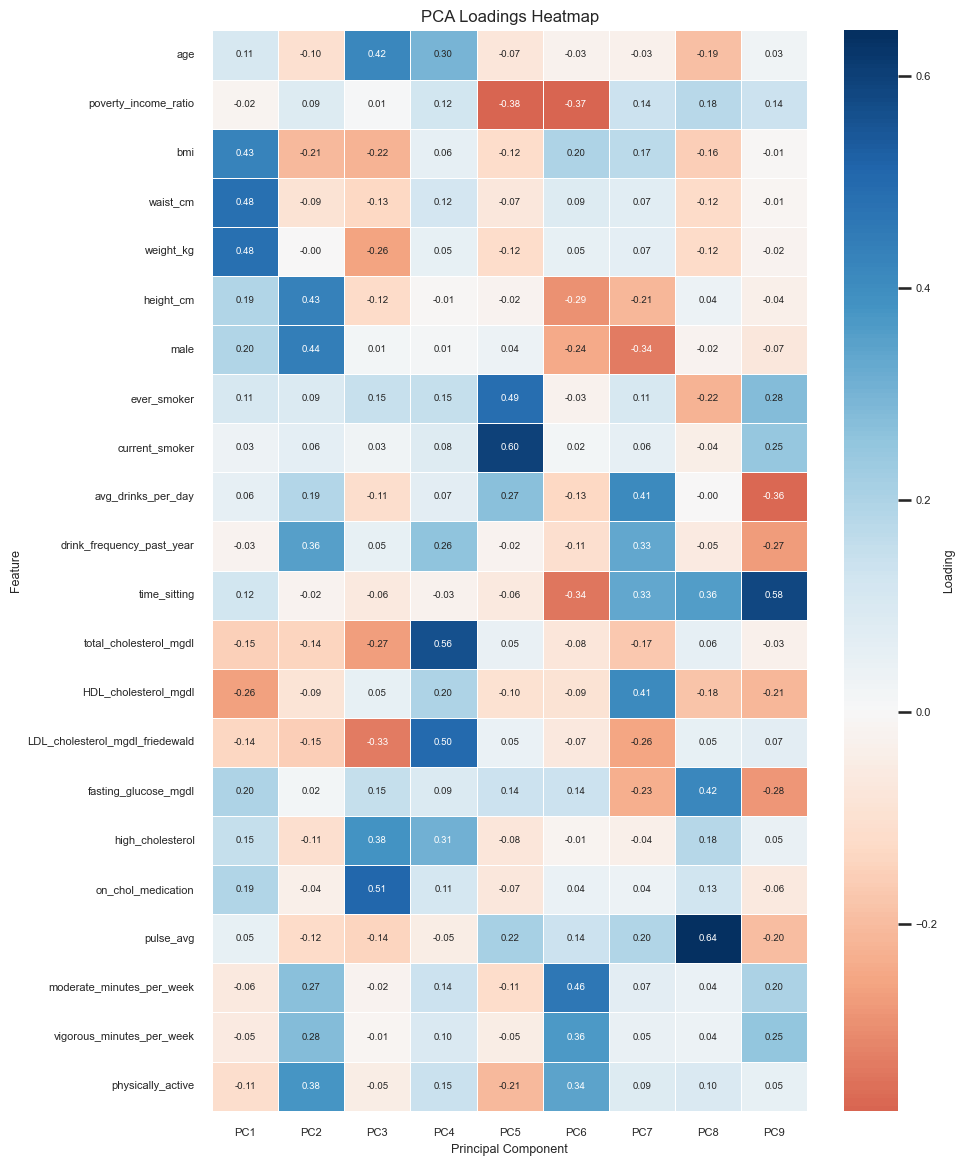

✔ Saved: C4.1_loadings_heatmap.png


In [121]:
plt.figure(figsize=(10, 12))

sns.heatmap(
    df_loadings,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    cmap='RdBu',      # diverging: red = negative, blue = positive
    center=0,           # 0 loading = white/neutral midpoint
    linewidths=0.5,
    cbar_kws={'label': 'Loading'}
)

plt.title('PCA Loadings Heatmap', fontsize=12)
plt.xlabel('Principal Component', fontsize=9)
plt.ylabel('Feature', fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Loading', fontsize=9)

plt.tight_layout()
plt.savefig(f"{output_dir}/C4.1_loadings_heatmap.png", dpi=150)
plt.show()
print("✔ Saved: C4.1_loadings_heatmap.png")